# Handwritten Digit Classification

In this project, I will build a machine learning algorithm to classify handwritten digits using image features.

In [ ]:
from datasets import Dataset
from datasets import load_from_disk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
import cv2
from tqdm import tqdm
from scipy.stats import entropy
from scipy.ndimage import rotate, shift
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import hog, local_binary_pattern
from scipy.ndimage import median_filter
from skimage.measure import label, regionprops
import pandas as pd
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC

### Dataset Description

The dataset consists of images of handwritten digits from 10 classes, representing the digits `0` through `9`. These images are grayscale and have been resized to a standard size (e.g., 28x28 pixels).

The dataset has been purposely modified to include some **unlabeled images**, **noisy samples**, and **synthetically augmented data** for certain classes. I will  clean the data, handle the noise, and ensure that the dataset is ready for effective model training.

In [9]:
dataset = load_from_disk('digit_data')
first_samples = dataset['train'].select(range(25))

images = first_samples['image']
labels = first_samples['label']

In [10]:
# function to display rows * cols first samples from images
def show_grid(images, labels, rows=5, cols=5, figsize=(8, 5), cmap='gray'):
    if len(images) != len(labels):
        print("Warning: number of images and labels isn't the same.")

    total_slots = rows * cols
    n = len(images)

    if n == 0:
        print("Warning: no images to display.")
        return
    elif n < total_slots:
        print(f"Warning: only {n} images provided, but grid has {total_slots} slots.")

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flat

    for i in range(total_slots):
        ax = axs[i]
        if i < n:
            ax.imshow(np.array(images[i]), cmap=cmap)
            ax.set_title(f"Label: {labels[i]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

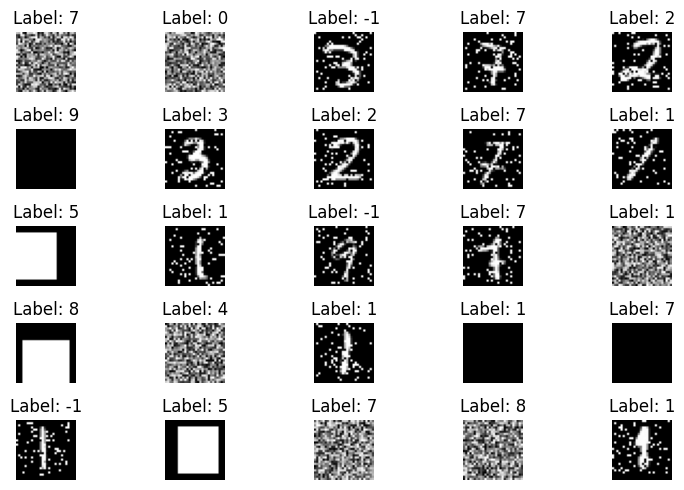

In [11]:
show_grid(images, labels)

As we can see, the dataset contains various types of irrelevant images, such as empty images, unlabeled samples (**labeled as -1**), noisy images, and images containing large rectangles.

These artifacts were intentionally introduced and will need to be identified and filtered out during the data cleaning process.

Additionally, based on these initial samples, we can anticipate some imbalance in the dataset, which will require careful handling to ensure fair and accurate model training.


**Draw a plot with distribution of the classes**

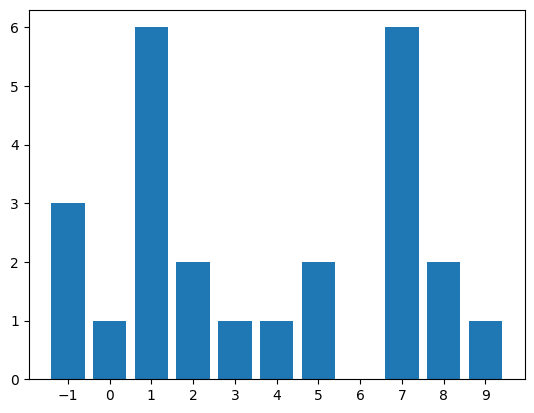

In [12]:
plt.bar(*np.unique(labels, return_counts=True))
plt.xticks(np.arange(min(labels), max(labels)+1, 1))
plt.show()

### Data cleaning

**Let's filter out unlabeled samples**

In [13]:
# filters out samples which do not match by predicate and returns cleaned and filtered datasets
def filter_dataset(ds, predicate):
    cleaned_ds = ds.filter(lambda e: not predicate(e))  # filter iterates over the data ds -> e = each iteration
    filtered_ds = ds.filter(lambda e: predicate(e))
    return cleaned_ds, filtered_ds

In [14]:
# predicate for removing unlabeled samples. Similiarly you are supposed to write other predicates
def is_unlabeled(sample):
    return sample['label'] == -1

In [15]:
dataset_wo_unlabeled, unlabeled_samples = filter_dataset(dataset, is_unlabeled)

Filter:   0%|          | 0/193710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/32341 [00:00<?, ? examples/s]

Filter:   0%|          | 0/193710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/32341 [00:00<?, ? examples/s]

Let's display our cleaned dataset and samples that we have filtered out.

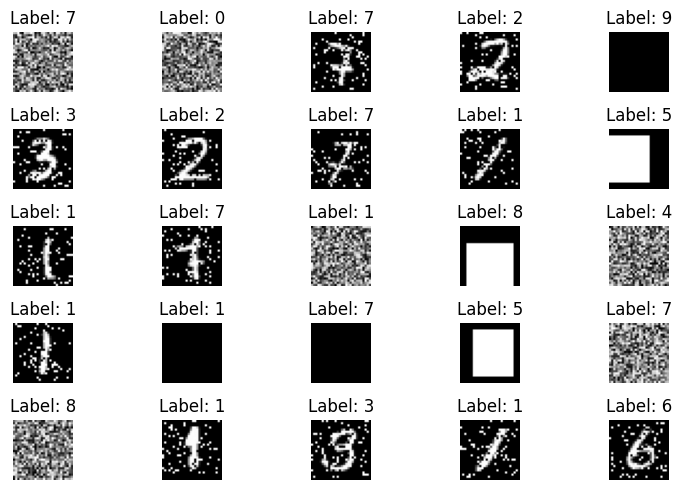

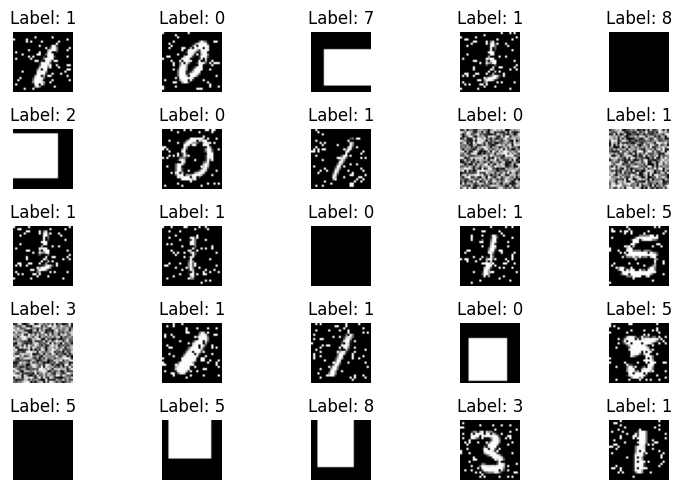

In [16]:
show_grid(dataset_wo_unlabeled['train']['image'], dataset_wo_unlabeled['train']['label'])   # cleaned_df -> train
show_grid(dataset_wo_unlabeled['test']['image'], dataset_wo_unlabeled['test']['label'])     # cleaned_df -> test

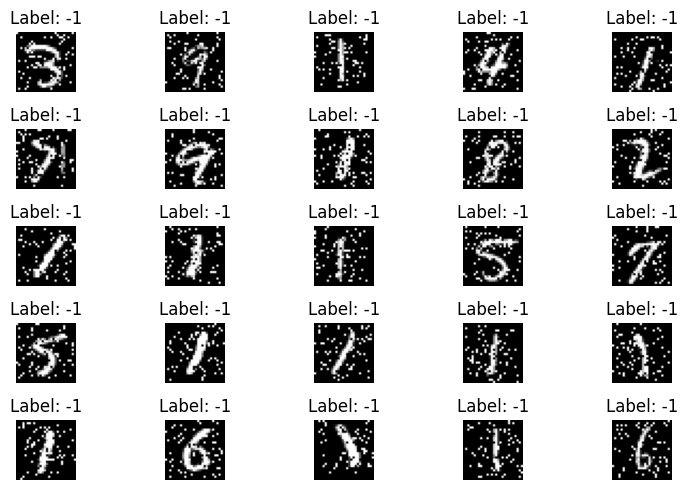

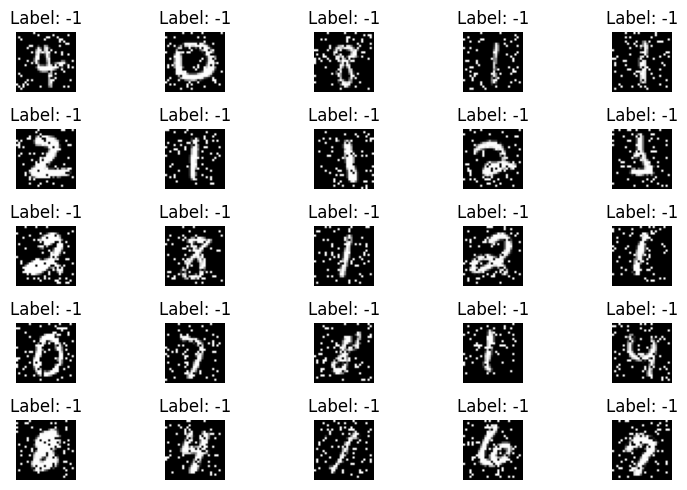

In [17]:
show_grid(unlabeled_samples['train']['image'], unlabeled_samples['train']['label'])         # samples of filtered data -> train
show_grid(unlabeled_samples['test']['image'], unlabeled_samples['test']['label'])           # samples of filtered data -> test

# Note: Since the unlabeled images are fine (based on quality) but just not labeled one could use them later to classify
# them with the then existing model and use them as additional images/features instead of data augmentation. 
# This won't be done in this example because of time constraints and because also in this version the needed acurracy
# is already reached. 

**Filter out empty images**  
Here we want to remove only images which contain **nothing**.

In [18]:
def is_empty(sample):
    return np.std(np.array(sample['image'])) == 0

In [19]:
dataset_wo_empty, empty_samples = filter_dataset(dataset_wo_unlabeled, is_empty)

Filter:   0%|          | 0/163710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/27341 [00:00<?, ? examples/s]

Filter:   0%|          | 0/163710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/27341 [00:00<?, ? examples/s]

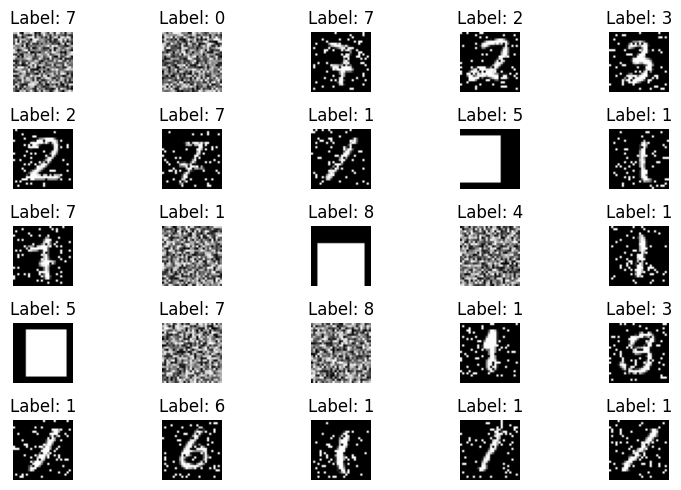

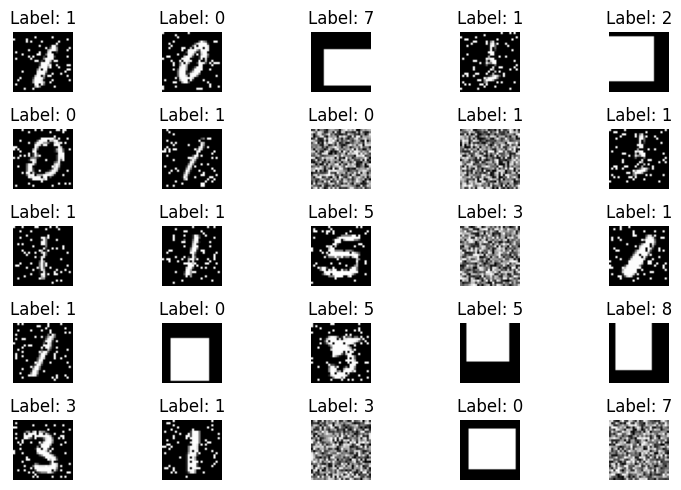

In [20]:
show_grid(dataset_wo_empty['train']['image'], dataset_wo_empty['train']['label'])   # show_grid shows only first 5 rows/columns
show_grid(dataset_wo_empty['test']['image'], dataset_wo_empty['test']['label'])

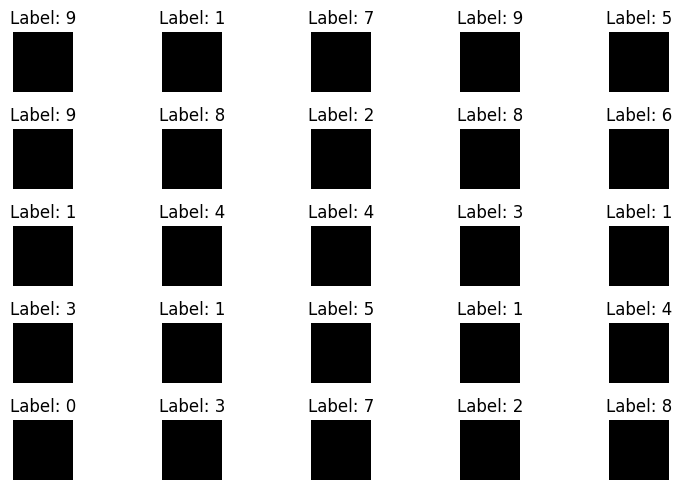

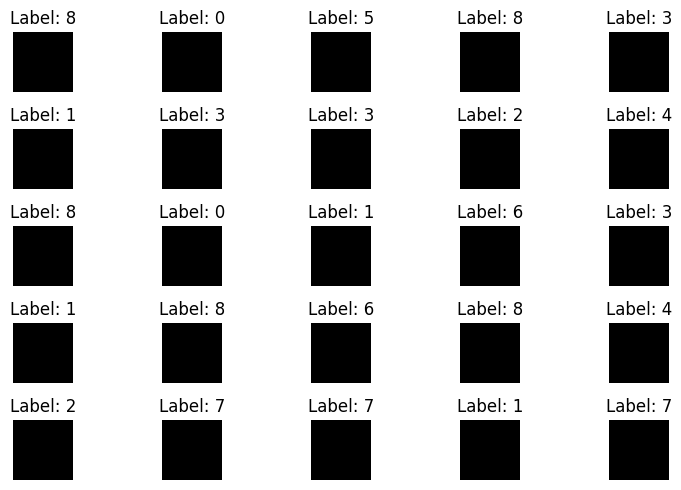

In [21]:
show_grid(empty_samples['train']['image'], empty_samples['train']['label'])
show_grid(empty_samples['test']['image'], empty_samples['test']['label'])

**Filter out noisy data**  
Here we want to remove only images which contain **ONLY** noise. Images containing **digits** must remain in the dataset (even if they have some noise).

In [22]:
def is_noisy(sample):
    img = np.array(sample['image'])
    label = sample['label']
    counts, _ = np.histogram(img, bins=256, range=(0, 256))
    probs = counts / img.size
    ent = entropy(probs, base=2)
    return ent > 7  #! Describes amount of choas (distribution of pixel brightness, if equal => all pixels equally often present)

In [23]:
dataset_wo_noisy, noisy_samples = filter_dataset(dataset_wo_empty, is_noisy)

Filter:   0%|          | 0/143706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/24007 [00:00<?, ? examples/s]

Filter:   0%|          | 0/143706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/24007 [00:00<?, ? examples/s]

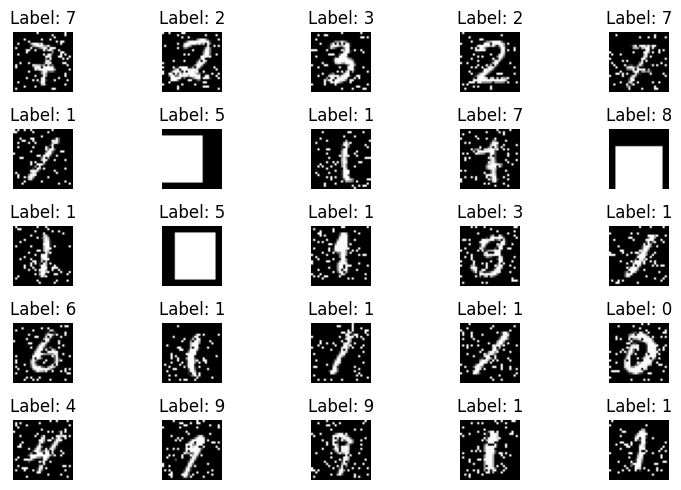

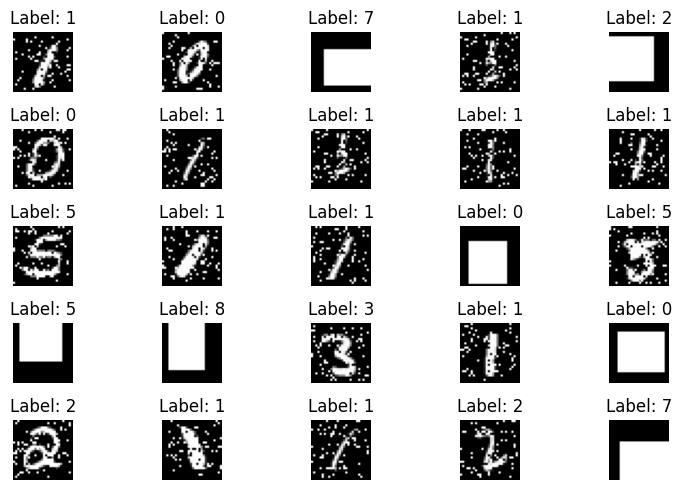

In [24]:
show_grid(dataset_wo_noisy['train']['image'], dataset_wo_noisy['train']['label'])
show_grid(dataset_wo_noisy['test']['image'], dataset_wo_noisy['test']['label'])

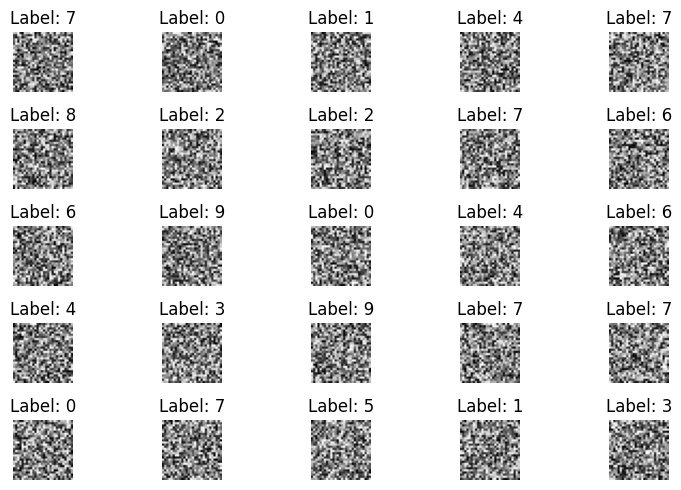

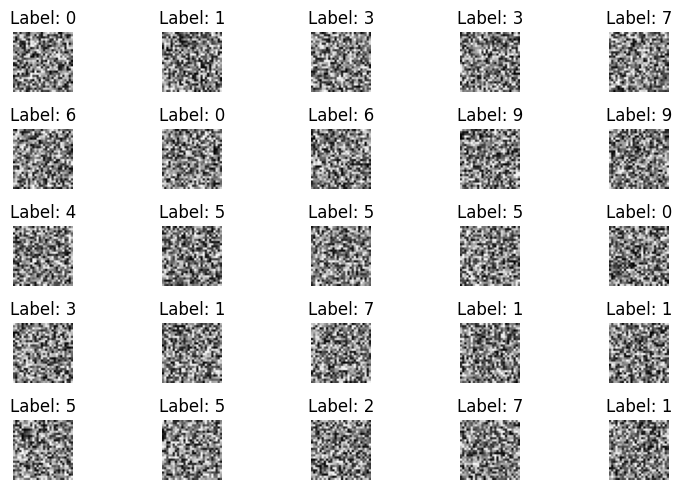

In [25]:
show_grid(noisy_samples['train']['image'], noisy_samples['train']['label'])
show_grid(noisy_samples['test']['image'], noisy_samples['test']['label'])

**Filter out samples with a large rectangle**  
Here we want to remove images which contain **large white rectangle**.

In [26]:
def has_large_rectangle(sample):
    # 1. Converting image into np.Array
    img = np.array(sample['image'])
    
    # 2. Creating Binary Values (Thresholding)
    # We consider something as white if the brightness is > 200.
    # The results is a matrix with True and False values.
    mask = img > 200

    # 3. np.where return the position coordinates of all the true values
    # => dimension calculatable.
    rows, cols = np.where(mask)
    
    # We find the extrem points to create hights and widths
    min_row, max_row = rows.min(), rows.max()
    min_col, max_col = cols.min(), cols.max()
    
    # 4. The + 1 is needed to not get steps in distance but complete
    # widths and hights
    height = max_row - min_row + 1
    width = max_col - min_col + 1
    
    rect_area = height * width
    total_image_area = img.size

    # 5. Understanding if rect_area is filled with
    # white pixels
    actual_white_pixels = np.sum(mask)

    # If the recangle is filled => The following is 1:
    density = actual_white_pixels / rect_area

    return density == 1

#! We find extreme points which are brighter than 200 => Create area => If all area is > 200 => white area.

In [27]:
dataset_wo_rectangles, samples_with_rectangles = filter_dataset(dataset_wo_noisy, has_large_rectangle)

Filter:   0%|          | 0/113706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19007 [00:00<?, ? examples/s]

Filter:   0%|          | 0/113706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19007 [00:00<?, ? examples/s]

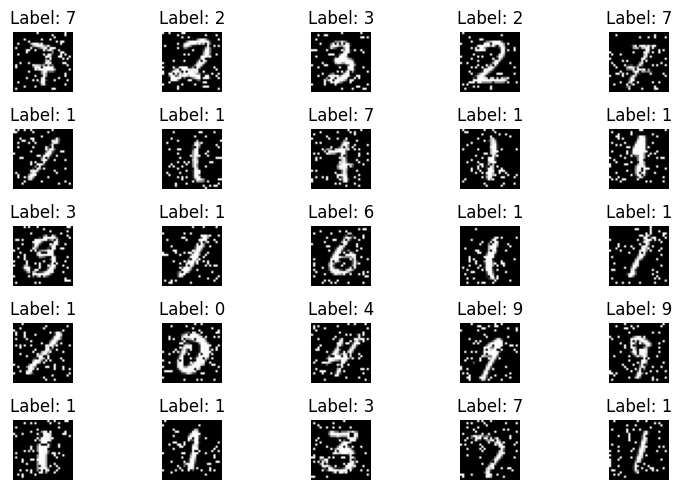

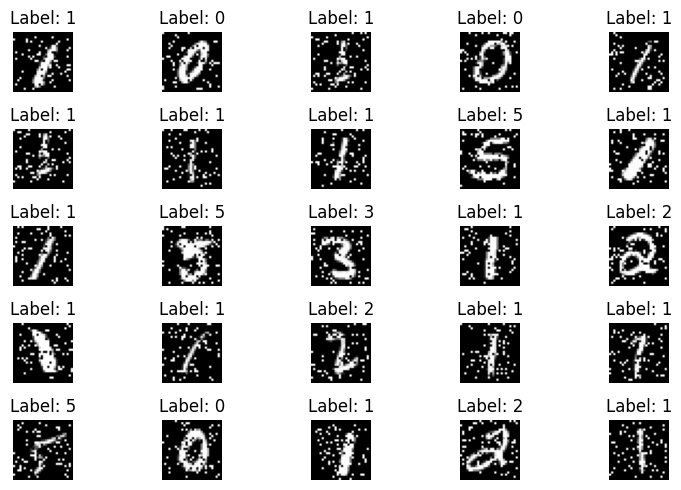

In [28]:
show_grid(dataset_wo_rectangles['train']['image'], dataset_wo_rectangles['train']['label'])
show_grid(dataset_wo_rectangles['test']['image'], dataset_wo_rectangles['test']['label'])

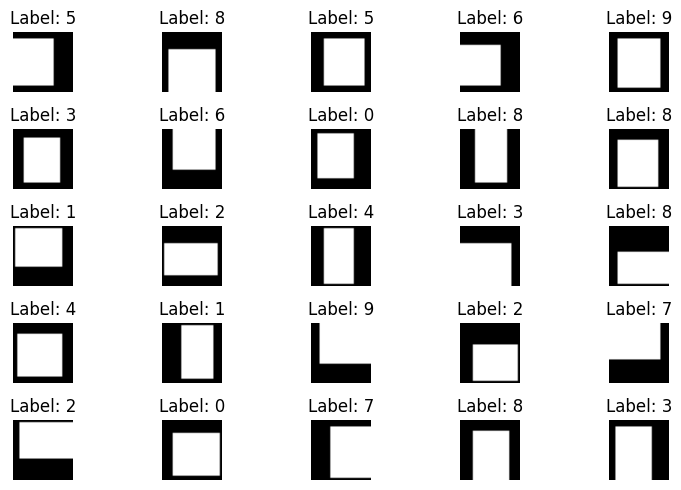

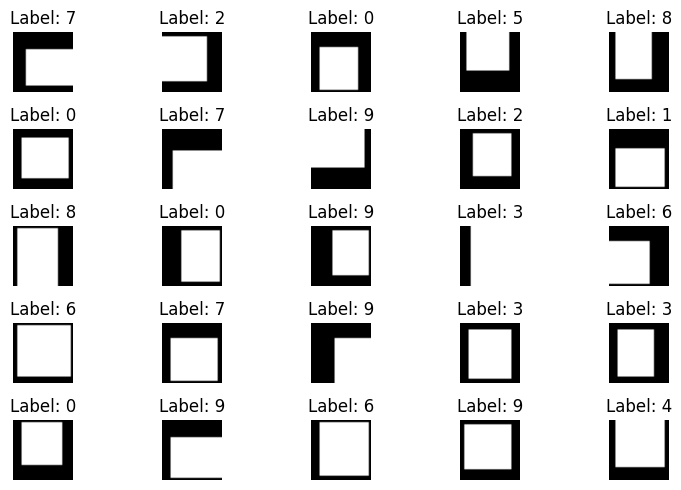

In [29]:
show_grid(samples_with_rectangles['train']['image'], samples_with_rectangles['train']['label'])
show_grid(samples_with_rectangles['test']['image'], samples_with_rectangles['test']['label'])

Preprocessing: **(ADV) Apply image preprocessing techniques to reduce impact of the noise**

In [30]:
filtered_ds = dataset_wo_rectangles

def denoise_dataset(dataset):
    cleaned_images = []

    # Iterating through all images
    for img in tqdm(dataset['image']):
        img_arr = np.array(img)
        
        # Median-Filter
        # size=3 means: We always look at a 3x3 window
        denoised_img = median_filter(img_arr, size=3)
        
        cleaned_images.append(denoised_img)
        
    return cleaned_images

#! Takes the median of all the pixels arround him (the current pixel) and translates it into the median of the 
#! sorrounding.

# --- Applying ---

# We use it on filtered_ds Train and Test:

# 1. Train Dataset
clean_train_imgs = denoise_dataset(filtered_ds['train'])

# Since HuggingFace Datasets are immutable we must replace the complete old data
filtered_ds['train'] = Dataset.from_dict({
    'image': clean_train_imgs,
    'label': filtered_ds['train']['label']
})

100%|██████████| 93710/93710 [00:17<00:00, 5450.48it/s]


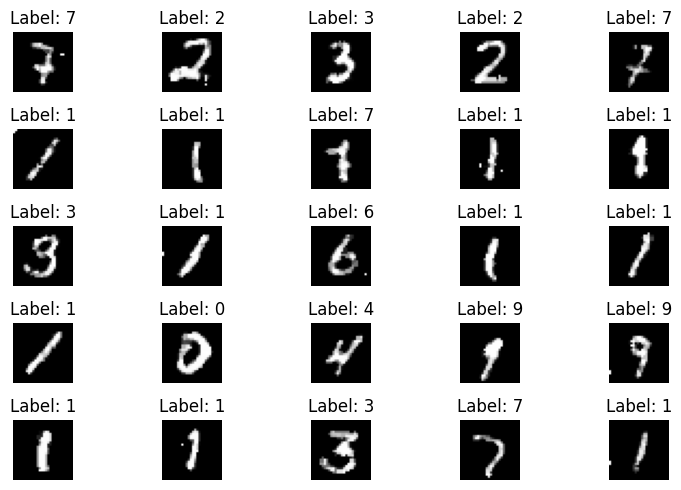

In [31]:
show_grid(filtered_ds['train']['image'], filtered_ds['train']['label'])

In [32]:
# 2. Test Dataset
clean_test_imgs = denoise_dataset(filtered_ds['test'])

filtered_ds['test'] = Dataset.from_dict({
    'image': clean_test_imgs,
    'label': filtered_ds['test']['label']
})

100%|██████████| 15675/15675 [00:02<00:00, 5438.87it/s]


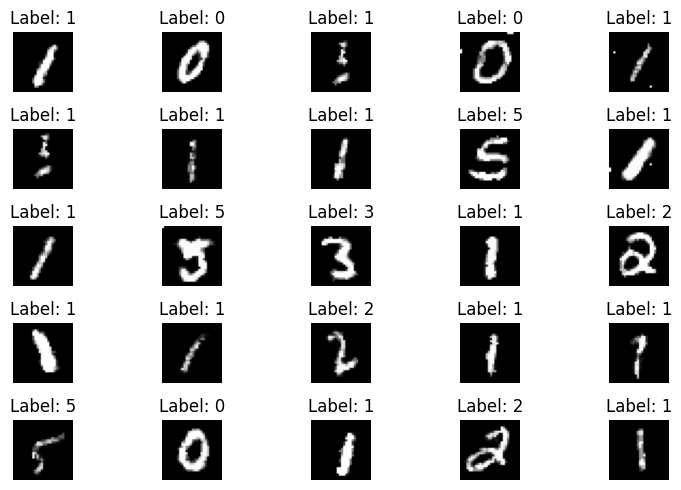

In [33]:
show_grid(filtered_ds['test']['image'], filtered_ds['test']['label'])

This is the final filtering step. Let's rename the ds to more convenient ```This was done already```

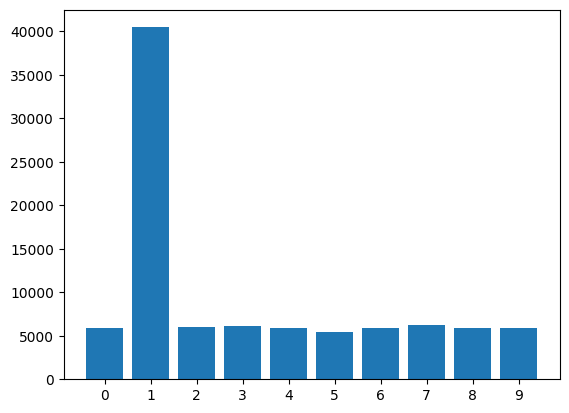

In [34]:
# Controlling Distribution of Digits
# Train Data
plt.bar(*np.unique(filtered_ds['train']['label'], return_counts=True))
plt.xticks(np.unique(filtered_ds['train']['label']))
plt.show()

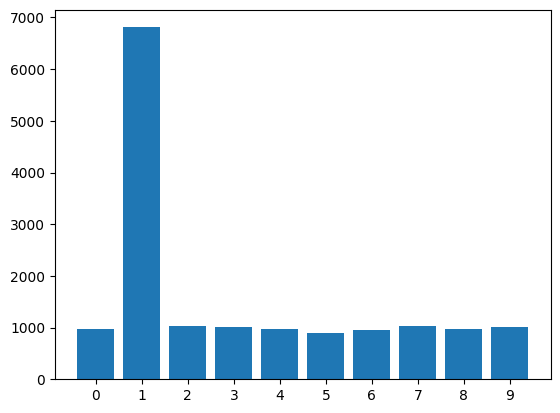

In [35]:
# Test Data
plt.bar(*np.unique(filtered_ds['test']['label'], return_counts=True))
plt.xticks(np.unique(filtered_ds['test']['label']))
plt.show()

### Imbalance in Classes

From the visualization, you can observe an imbalance in the classes. To address this, consider applying techniques such as:

- **Oversampling**: Increase the number of samples in the minority class.
- **Undersampling**: Reduce the number of samples in the majority class.
- **Class Weighting**: Adjust model training by assigning different weights to classes. For most machine learning algorithms, class weighting is supported in **`sklearn`** by passing the `class_weight` parameter (see documentation e.g [Random Forest](https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestClassifier.html)).
- **Data Augmentation**: Generate more diverse data for underrepresented classes by transforming existing samples. This can include techniques like rotating, scaling, or adding noise to the images.

**Apply oversampling or undersampling**

In [36]:
# ------------------------------------------------------------------
# Defining Feature Extraction Function (Same as the one later used)
# ------------------------------------------------------------------
# This step is needed to generate the Learning Curve later to understand if oversampling or downsampling is needed.
def extract_features(images):
    features = []
    
    print("Extracting Features...")
    
    for image in tqdm(images):
        
        # --- A. Basic Features ---
        avg_intensity = np.mean(image)
        std_intensity = np.std(image)
        hist_pixels, _ = np.histogram(image, bins=10, range=(0, 1))
        horizontal_projection = np.sum(image, axis=1)
        vertical_projection = np.sum(image, axis=0)
        
        # --- B. Form-Invariant Features ---
        # Symmetry
        img_flip_h = np.fliplr(image)
        symmetry_h = np.mean(np.abs(image - img_flip_h))
        img_flip_v = np.flipud(image)
        symmetry_v = np.mean(np.abs(image - img_flip_v))
        
        # Crossings (Crossing of horizontal and vertical line)
        mid_row = (image[14, :] > 0.5).astype(int)
        mid_col = (image[:, 14] > 0.5).astype(int)
        crossings_h = np.sum(np.abs(np.diff(mid_row))) / 2
        crossings_v = np.sum(np.abs(np.diff(mid_col))) / 2
        
        # Hu Moments (Describing the Form)
        moments = cv2.moments(image)
        hu_moments = cv2.HuMoments(moments).flatten()
        # Log-Scale ffor better Readability
        hu_moments_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

        # --- C. HOG (Histogram of Oriented Gradients) ---
        # HOG divides the image into cells and looks at the direction of the edges.
        # orientations=9: We distinguish between 9 directions (0°, 20°, 40°...).
        # pixels_per_cell=(7, 7): Since the image is 28x28, we get a 4x4 grid (16 cells).
        # This results in a larger feature vector (9 directions * 16 cells = 144 features).
        hog_features = hog(image, orientations=9, pixels_per_cell=(14, 14),
                           cells_per_block=(1, 1), block_norm='L2-Hys', visualize=False)
                           
        # --- D. LBP (Local Binary Patterns) ---
        # LBP describes the texture of the image by comparing each pixel with its neighbors.
        # P=8, R=1: We examine the 8 immediate neighbors within a radius of 1 pixel.
        # If a neighbor's intensity is greater than or equal to the center pixel, it's marked 1, otherwise 0.
        # This creates an 8-bit binary number for each pixel, representing local structure (like edges or corners).
        # Using method='uniform' reduces noise by grouping similar patterns into a smaller number of categories.
        radius = 1
        n_points = 8 * radius
        # 'uniform': Reduziert die Muster auf die wichtigsten
        lbp = local_binary_pattern(image, n_points, radius, method='uniform')

        # LBP returns a image. => We use the histogram of it as feature
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))
        
        # Normalizing LBP histogram (So it stays comparable)
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-7)

        # --- Summarizing ---
        feature_vector = np.hstack([
            [avg_intensity, std_intensity], # 2
            hist_pixels,                    # 10
            horizontal_projection,          # 28
            vertical_projection,            # 28
            [symmetry_h, symmetry_v],       # 2
            [crossings_h, crossings_v],     # 2
            hu_moments_log,                 # 7
            hog_features,                   # 36 (bei 14x14 cells)
            lbp_hist                        # 10 (bei P=8 uniform)
        ])
        
        features.append(feature_vector)

    return np.array(features)

In [37]:
# ------------------------------------------------------
# Extracting the Features based on the cleaned data set
# ------------------------------------------------------
# Extracting the images as np.arrays and extracting the labels
X_train = np.array([np.array(img) for img in filtered_ds['train']['image']])
y_train = np.array(filtered_ds['train']['label'])

X_test = np.array([np.array(img) for img in filtered_ds['test']['image']])
y_test = np.array(filtered_ds['test']['label'])

# Normalizing the features to make them between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Extracting the Features
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

Extracting Features...


  0%|          | 0/93710 [00:00<?, ?it/s]c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 93710/93710 [02:18<00:00, 675.80it/s]


Extracting Features...


100%|██████████| 15675/15675 [00:23<00:00, 663.99it/s]


In [38]:
# ---------------------------------------------------------
# Generation of a Pipeline for the Learning Curve Creation
# ---------------------------------------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000))
])

Starting the Learning Curve Process...
Datapool Class 1: 40452 Samples.
Datapool of other classes (fix): 53258 Samples.
------------------------------
Class 1 Size: 5000 | Accuracy: 0.9409
Class 1 Size: 10000 | Accuracy: 0.9446
Class 1 Size: 15000 | Accuracy: 0.9445
Class 1 Size: 20000 | Accuracy: 0.9451
Class 1 Size: 25000 | Accuracy: 0.9451
Class 1 Size: 30000 | Accuracy: 0.9456
Class 1 Size: 35000 | Accuracy: 0.9454
Class 1 Size: 40000 | Accuracy: 0.9448


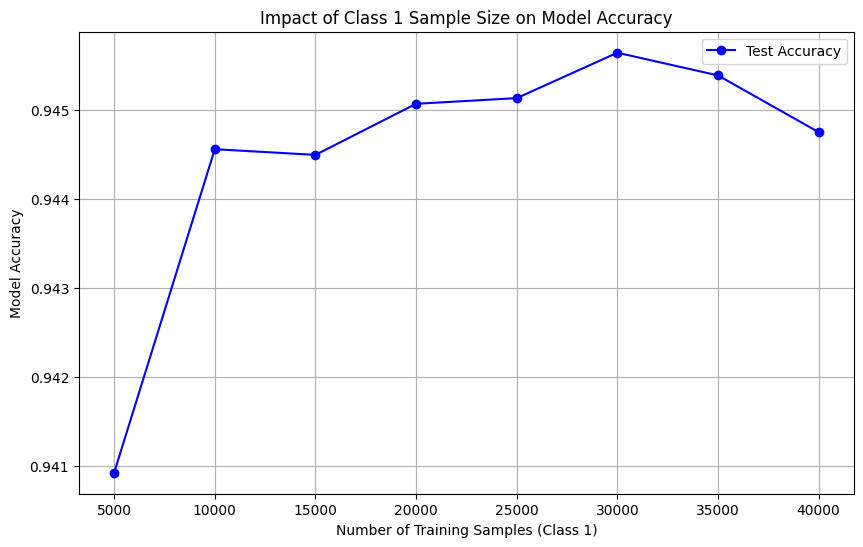

In [39]:
# ---------------------------
# Learning Curve for Class 1 
# ---------------------------
def create_class1_learning_curve(X_train_feats, y_train, X_test_feats, y_test, pipeline):# 1. We distinguish between "Class 1" and the "Rest"
    # We work directly upon the features to reduce computation time
    indices_class_1 = np.where(y_train == 1)[0]
    indices_others = np.where(y_train != 1)[0]
    
    # Splitting Features and Labels
    X_1 = X_train_feats[indices_class_1]
    y_1 = y_train[indices_class_1]
    
    X_others = X_train_feats[indices_others]
    y_others = y_train[indices_others]

    # Maximal amount of available 1s
    max_class_1 = len(X_1)
    
    # Lists to save the results
    counts = []
    accuracies = []
    
    print(f"Starting the Learning Curve Process...")
    print(f"Datapool Class 1: {max_class_1} Samples.")
    print(f"Datapool of other classes (fix): {len(X_others)} Samples.")
    print("-" * 30)

    #2. For Loop: We start with 5000 1-samples and increase 5000/step
    for count in range(5000, max_class_1 + 1, 5000):
        
        # A. We only take the first "count" values of 1s
        current_X_1 = X_1[:count]
        current_y_1 = y_1[:count]
        
        # B. We add them to all the other classes
        X_train_current = np.vstack((current_X_1, X_others))
        y_train_current = np.hstack((current_y_1, y_others))
        
        # C. Training the model upon that Feature Subset
        # Fitting the Random Forest Classifier
        pipeline.fit(X_train_current, y_train_current)
        
        # D. Evaluation based on the fixed Test set
        y_pred = pipeline.predict(X_test_feats)
        acc = accuracy_score(y_test, y_pred)
        
        # Saving results
        counts.append(count)
        accuracies.append(acc)
        
        print(f"Class 1 Size: {count} | Accuracy: {acc:.4f}")

    # 3. Plotting the Curve
    plt.figure(figsize=(10, 6))
    plt.plot(counts, accuracies, marker='o', linestyle='-', color='b', label='Test Accuracy')
    
    plt.title('Impact of Class 1 Sample Size on Model Accuracy')
    plt.xlabel('Number of Training Samples (Class 1)')
    plt.ylabel('Model Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Applying the Function ---
# We use the previously extracted features
create_class1_learning_curve(X_train_features, y_train, X_test_features, y_test, pipeline)
# -> 30.000 Samples of class 1 are enough to acchieve the highest acurracy

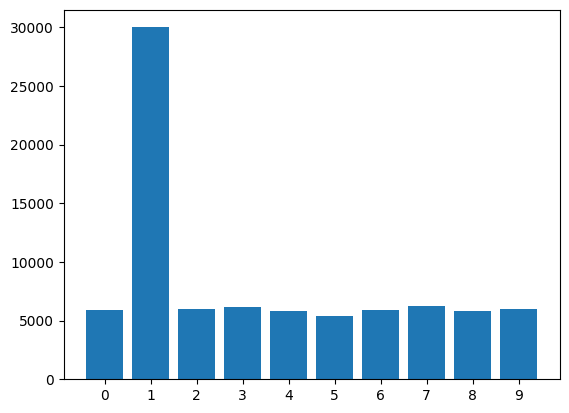

In [40]:
# ---------------------
# Downsampling class 1
# ---------------------
# Keeping only 25.000 1s
def downsample_class_1(dataset, target_count=30000):
    # 1. Transforming labels into np.array
    labels = np.array(dataset['label'])
    
    # 2. Finding all Indices with label == 1
    indices_1 = np.where(labels == 1)[0]
    indices_rest = np.where(labels != 1)[0]

    # 3. Choosing random 15.000 1s
    np.random.seed(42) 
    indices_1_downsampled = np.random.choice(indices_1, size=target_count, replace=False)
    
    # 4. Reconnecting all 15.000 1s with the other labels
    all_indices = np.concatenate([indices_1_downsampled, indices_rest])
    
    # 5. Shuffling => The 1s are not all at the beginning
    np.random.shuffle(all_indices)
    
    # 6. Keeping only the selected indices
    return dataset.select(all_indices)

# We apply it on the Training Dataset
filtered_ds['train'] = downsample_class_1(filtered_ds['train'])
plt.bar(*np.unique(filtered_ds['train']['label'], return_counts=True))
plt.xticks(np.unique(filtered_ds['train']['label']))
plt.show()

In [41]:
# ------------------------------------------------------
# Extracting the Features based on the downsampled data set
# ------------------------------------------------------
# Extracting the images as np.arrays and extracting the labels
X_train = np.array([np.array(img) for img in filtered_ds['train']['image']])
y_train = np.array(filtered_ds['train']['label'])

X_test = np.array([np.array(img) for img in filtered_ds['test']['image']])
y_test = np.array(filtered_ds['test']['label'])

# Normalizing the features to make them between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Extracting the Features
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

Extracting Features...


  0%|          | 0/83258 [00:00<?, ?it/s]c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 83258/83258 [02:07<00:00, 651.06it/s]


Extracting Features...


100%|██████████| 15675/15675 [00:25<00:00, 610.98it/s]


**(ADV) Apply data augmentations**

In [42]:
# -------------------------------------
# Learning Curve for Data Augmentation
# -------------------------------------
# We learned from class 1 that we should have 30.000 samples to accieve the best acurracy. We will take
# those 30.000 as a reference for the maximum amount of augmented data we will generate.

# --- 1. The Augmentation Function ---
def augment_image(original_image):
    img = np.array(original_image)
    # Turning the image randomly
    angle = np.random.uniform(-10, 10)
    img_aug = rotate(img, angle, reshape=False, mode='constant', cval=0, order=0)
    dy, dx = np.random.randint(-2, 3, size=2)
    # Shifting the image randomly
    img_aug = shift(img_aug, [dy, dx], mode='constant', cval=0, order=0)
    return img_aug


# --- 2. Preparation: Features and Labels of the Non-Augmented Data (already existing) ---
# X_train_features
# y_train
# X_test_features
# y_test


# --- 3. Creating one Data Pool with the Maximum of Synthetic Images (Features) ---
def create_synthetic_feature_pool(dataset, target_total=25000):
    synthetic_features_pool = {}
    synthetic_images_pool = {}
    
    print(f"Generating synthetic Featurepool (Goal: {target_total} per class)...")
    
    for digit_class in [0, 2, 3, 4, 5, 6, 7, 8, 9]:
        # Finding the original images for each class
        original_imgs = [img for img, label in zip(dataset['image'], dataset['label']) if label == digit_class]
        current_count = len(original_imgs)
        
        # How many are needed to acchieve target_total?
        needed_max = target_total - current_count
        
        if needed_max <= 0:
            synthetic_features_pool[digit_class] = None
            continue
            
        print(f"\nClass {digit_class}: Generating {needed_max} synthetic samples...")
        
        temp_aug_images = []
        # We generate the maximum amount of Augmented Features needed
        for _ in range(needed_max):
            # Choosing random image from the original images
            random_idx = np.random.randint(0, current_count)
            original_norm = np.array(original_imgs[random_idx]) / 255.0
            
            # Augmenting
            new_img = augment_image(original_norm)
            temp_aug_images.append(new_img)
        
        # Extracting and saving the features of the new image
        feats = extract_features(np.array(temp_aug_images))
        synthetic_features_pool[digit_class] = feats
        synthetic_images_pool[digit_class] = temp_aug_images
        
    return synthetic_features_pool, synthetic_images_pool

In [43]:
# Applying the function on the original Train Set 
synth_pool_features, synth_pool_images = create_synthetic_feature_pool(filtered_ds['train'])

Generating synthetic Featurepool (Goal: 25000 per class)...

Class 0: Generating 19077 synthetic samples...
Extracting Features...


100%|██████████| 19077/19077 [00:31<00:00, 609.92it/s]



Class 2: Generating 19042 synthetic samples...
Extracting Features...


100%|██████████| 19042/19042 [00:31<00:00, 599.13it/s]



Class 3: Generating 18869 synthetic samples...
Extracting Features...


...

100%|██████████| 18735/18735 [00:29<00:00, 626.76it/s]



Class 8: Generating 19149 synthetic samples...
Extracting Features...


100%|██████████| 19149/19149 [00:29<00:00, 655.65it/s]



Class 9: Generating 19051 synthetic samples...
Extracting Features...


100%|██████████| 19051/19051 [00:34<00:00, 553.19it/s]


In [44]:
# --- 4. Creating the Learning Curve ---
def run_augmentation_learning_curve(X_orig, y_orig, synth_pool, X_test, y_test, pipeline):
    
    steps = []
    accuracies = []
    
    # augmentation steps defines the amount of additional augmented features
    # (images) we include to the original features. To acchieve the maximum
    # of 25.000 features (based on ~5.000 already existing original features)
    # we add a maximum of 20.000 additional augmented features.
    augmentation_steps = range(0, 20001, 2000) 
    
    print("Starting Learning Curve Process...\n")
    
    for n_added in augmentation_steps:
        # Start: Oll Original Features
        X_current_train = [X_orig]
        y_current_train = [y_orig]
        
        # We add the agumented features per digit class (except 1)
        for digit_class in [0, 2, 3, 4, 5, 6, 7, 8, 9]:
            if digit_class in synth_pool and synth_pool[digit_class] is not None:
                
                # We take the first n_added features from the augmented features pool
                # (If n_added > compared to what is given in features pool => Take all
                # augmented features)
                pool_data = synth_pool[digit_class]
                limit = min(n_added, len(pool_data))
                
                if limit > 0:
                    X_current_train.append(pool_data[:limit])
                    y_current_train.append(np.full(limit, digit_class)) # Creates a np.array full of numbers
                                                                        # of digit_class of length limit
        # Stacking the Features and Labels
        X_train_stacked = np.vstack(X_current_train)    # Connects two lists vertically
        y_train_stacked = np.hstack(y_current_train)    # Connects two lists horizontally (To keep 1D shape and not matrix)
                                                        # -> Because y_current_train is a 1D np.array, while X_current_train
                                                        # is a matrix with rows
        # Training
        pipeline.fit(X_train_stacked, y_train_stacked)
        
        # Evaluating
        y_pred = pipeline.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        print(f"Added Synth/Class: {n_added} | Accuracy: {acc:.4f}")
        
        steps.append(n_added)
        accuracies.append(acc)
        
    # Plotting the Learning Curve based on additional augmented data
    plt.figure(figsize=(10, 6))
    plt.plot(steps, accuracies, marker='o', linestyle='-', color='green', label='Test Accuracy')
    plt.title('Effect of Synthetic Data Augmentation per Class')
    plt.xlabel('Number of Synthetic Images Added (Per Class)')
    plt.ylabel('Model Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

In [45]:
# --- 5. Applying ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000))
])

Starting Learning Curve Process...

Added Synth/Class: 0 | Accuracy: 0.9457
Added Synth/Class: 2000 | Accuracy: 0.9419
Added Synth/Class: 4000 | Accuracy: 0.9403
Added Synth/Class: 6000 | Accuracy: 0.9393
Added Synth/Class: 8000 | Accuracy: 0.9391
Added Synth/Class: 10000 | Accuracy: 0.9372
Added Synth/Class: 12000 | Accuracy: 0.9367
Added Synth/Class: 14000 | Accuracy: 0.9357
Added Synth/Class: 16000 | Accuracy: 0.9354
Added Synth/Class: 18000 | Accuracy: 0.9344
Added Synth/Class: 20000 | Accuracy: 0.9342


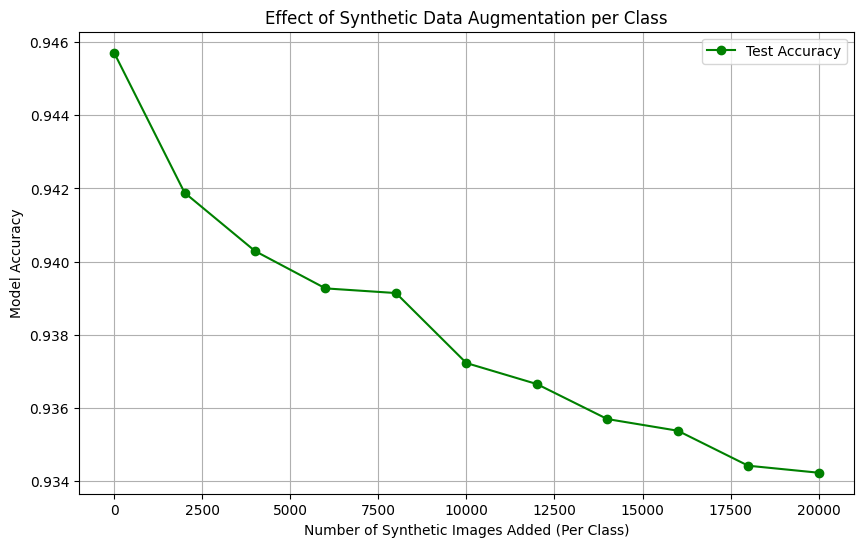

In [46]:
run_augmentation_learning_curve(X_train_features, y_train, synth_pool_features, X_test_features, y_test, pipeline)
# As we can see from the Learning Curve additional augmented data does not increase acurracy => We won't use data
# augmentation.

# -> No application of data augmentation on the test data! -> Otherwise we would test to recognize 
# unrealistic digits -> We only want to recognize realistic digits from the original data set. 

## Feature extraction

**Other features useful for classification**

In [47]:
# Adjusting existing extract_features function to additional features
# -> Adding the Euler Number: Counting the number of holes in a number
def extract_features(images):
    features = []
    
    print("Extracting Features...")
    
    for image in tqdm(images):
        # 1. Vorbereitung: 28x28 und sicherstellen, dass es float ist
        img = image.reshape(28, 28).astype(np.float32)
        
        # --- A. Basic Features ---
        avg_intensity = np.mean(img)
        std_intensity = np.std(img)
        hist_pixels, _ = np.histogram(img, bins=10, range=(0, 1))
        horizontal_projection = np.sum(img, axis=1)
        vertical_projection = np.sum(img, axis=0)
        
        # --- B. Form-Invariant Features ---
        # Symmetry
        img_flip_h = np.fliplr(img)
        symmetry_h = np.mean(np.abs(img - img_flip_h))
        img_flip_v = np.flipud(img)
        symmetry_v = np.mean(np.abs(img - img_flip_v))
        
        # Crossings (Crossing of horizontal and vertical line)
        mid_row = (img[14, :] > 0.5).astype(int)
        mid_col = (img[:, 14] > 0.5).astype(int)
        crossings_h = np.sum(np.abs(np.diff(mid_row))) / 2
        crossings_v = np.sum(np.abs(np.diff(mid_col))) / 2
        
        # Hu Moments (Describing the Form)
        moments = cv2.moments(img)
        hu_moments = cv2.HuMoments(moments).flatten()
        # Log-Scale ffor better Readability
        hu_moments_log = -np.sign(hu_moments) * np.log10(np.abs(hu_moments) + 1e-10)

        # --- C. HOG (Histogram of Oriented Gradients) ---
        # HOG teilt das Bild in Zellen und schaut, in welche Richtung die Kanten zeigen.
        # orientations=9: Wir unterscheiden 9 Richtungen (0°, 20°, 40°...)
        # pixels_per_cell=(14, 14): Da das Bild 28x28 ist, haben wir ein 2x2 Raster (4 Zellen).
        # Das hält den Feature-Vektor klein (9 Richtungen * 4 Zellen = 36 Features).
        hog_features = hog(img, orientations=9, pixels_per_cell=(7, 7),
                           cells_per_block=(1, 1), block_norm='L2-Hys', visualize=False)
                           
        # --- D. LBP (Local Binary Patterns) ---
        # LBP vergleicht jeden Pixel mit seinen Nachbarn.
        # P=8, R=1: Wir schauen uns die 8 direkten Nachbarn an (Radius 1).
        radius = 1
        n_points = 8 * radius
        # 'uniform': Reduziert die Muster auf die wichtigsten
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')

        # LBP returns a image. => We use the histogram of it as feature
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))
        
        # Normalizing LBP histogram (So it stays comparable)
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-7)

        # --- E: Euler Number (Holes) ---
        binary_img = img > 0.5
        label_img = label(binary_img) 
        # We only take the larget region (= digits) to avoid noise
        regions = regionprops(label_img)
        if regions:
            # Sorty by region size
            regions.sort(key=lambda x: x.area, reverse=True)
            euler_val = regions[0].euler_number # 1 = No hole, 0 = 1 Hole, -1 = 2 Holes
        else:
            euler_val = 1 # Fallback für leeres Bild

        # --- Summarizing ---
        feature_vector = np.hstack([
            [avg_intensity, std_intensity], # 2
            hist_pixels,                    # 10
            horizontal_projection,          # 28
            vertical_projection,            # 28
            [symmetry_h, symmetry_v],       # 2
            [crossings_h, crossings_v],     # 2
            [euler_val],                    # 1
            hu_moments_log,                 # 7
            hog_features,                   # 36 (bei 14x14 cells)
            lbp_hist                        # 10 (bei P=8 uniform)
        ])
        
        features.append(feature_vector)

    return np.array(features)

# --- Extracting the new Features based on the downsampled data set ---
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

Extracting Features...


  0%|          | 0/83258 [00:00<?, ?it/s]c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 83258/83258 [04:13<00:00, 328.46it/s]


Extracting Features...


100%|██████████| 15675/15675 [00:45<00:00, 347.51it/s]


## Model training

Let's create a pipeline and fit it

In [48]:
# Logistic Regression
pipeline_lg = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000))
])

pipeline_lg.fit(X_train_features, y_train);

Now we can evaluate the model on the test set

Model Accuracy: 0.9639
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.99      0.99      0.99      6810
           2       0.93      0.94      0.94      1032
           3       0.92      0.95      0.93      1010
           4       0.94      0.95      0.94       982
           5       0.95      0.93      0.94       892
           6       0.97      0.96      0.97       958
           7       0.94      0.93      0.94      1028
           8       0.94      0.94      0.94       974
           9       0.92      0.91      0.92      1009

    accuracy                           0.96     15675
   macro avg       0.95      0.95      0.95     15675
weighted avg       0.96      0.96      0.96     15675



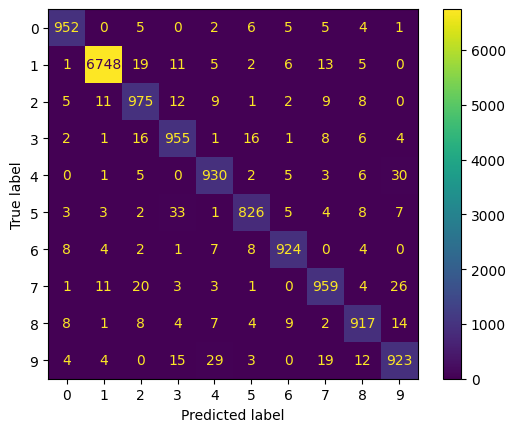

In [49]:
y_pred_lg = pipeline_lg.predict(X_test_features)

accuracy_lg = accuracy_score(y_test, y_pred_lg)
print(f"Model Accuracy: {accuracy_lg:.4f}")
print(classification_report(y_test, y_pred_lg))

ConfusionMatrixDisplay.from_estimator(pipeline_lg, X_test_features, y_test)
plt.show()

**Train other models and compare their performance**

Try training different models (at least 3) from sklearn and boosting libraries (e.g. Random Forest, SVM, Gradient Boosting, etc)

Model Accuracy: 0.9588
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       980
           1       0.99      0.99      0.99      6810
           2       0.93      0.95      0.94      1032
           3       0.90      0.92      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.94      0.90      0.92       892
           6       0.96      0.95      0.96       958
           7       0.95      0.92      0.93      1028
           8       0.94      0.92      0.93       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.96     15675
   macro avg       0.94      0.94      0.94     15675
weighted avg       0.96      0.96      0.96     15675



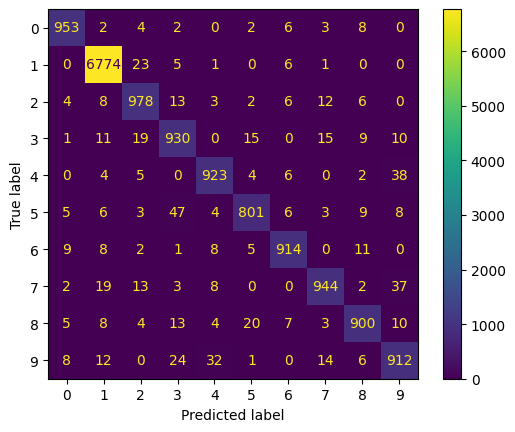

In [50]:
# ------------------------
# Fitting a Random Forest
# ------------------------
pipeline_rf = Pipeline([
    ('rf', RandomForestClassifier())
])

pipeline_rf.fit(X_train_features, y_train);

# --- Model Evaluation ---
y_pred_rf = pipeline_rf.predict(X_test_features)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Model Accuracy: {accuracy_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(pipeline_rf, X_test_features, y_test)
plt.show()

Model Accuracy: 0.9762
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      0.99      6810
           2       0.95      0.97      0.96      1032
           3       0.94      0.96      0.95      1010
           4       0.97      0.96      0.96       982
           5       0.96      0.96      0.96       892
           6       0.98      0.97      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.97      0.97       974
           9       0.94      0.94      0.94      1009

    accuracy                           0.98     15675
   macro avg       0.96      0.97      0.97     15675
weighted avg       0.98      0.98      0.98     15675



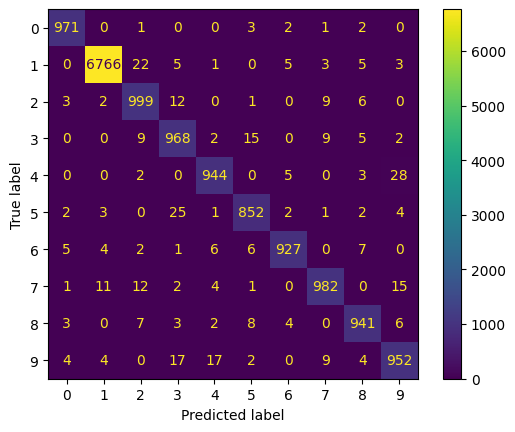

In [51]:
# ------------------
# Gradient Boosting
# ------------------
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()), # Für Boosting nicht zwingend, aber bei HOG gut
    ('gbm', HistGradientBoostingClassifier(
        max_iter=200,          # Anzahl der Bäume (Äquivalent zu n_estimators)
        learning_rate=0.1,     # Wie schnell er lernt
        max_depth=15,          # Tiefe der Bäume (wie beim Random Forest)
        random_state=42
    ))
])
pipeline_gb.fit(X_train_features, y_train)

# --- Model Evaluation ---
y_pred_gb = pipeline_gb.predict(X_test_features)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Model Accuracy: {accuracy_gb:.4f}")
print(classification_report(y_test, y_pred_gb))

ConfusionMatrixDisplay.from_estimator(pipeline_gb, X_test_features, y_test)
plt.show()

Model Accuracy: 0.9772
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       1.00      0.99      1.00      6810
           2       0.94      0.98      0.96      1032
           3       0.95      0.96      0.95      1010
           4       0.96      0.97      0.96       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.97      0.96      0.97       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.98     15675
   macro avg       0.97      0.97      0.97     15675
weighted avg       0.98      0.98      0.98     15675



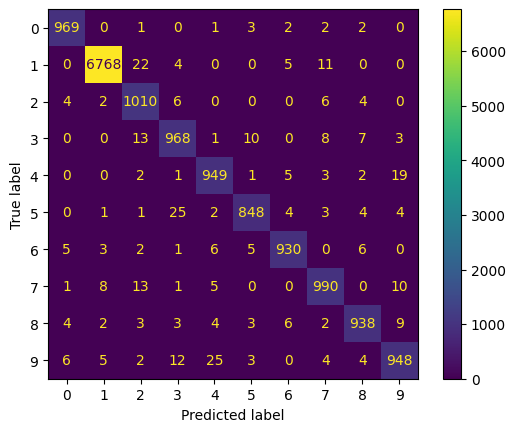

In [52]:
# ----
# SVM
# ----
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10.0, gamma='scale', cache_size=1000, random_state=42))
])
pipeline_svm.fit(X_train_features, y_train)

# --- Model Evaluation ---
y_pred_svm = pipeline_svm.predict(X_test_features)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Model Accuracy: {accuracy_svm:.4f}")
print(classification_report(y_test, y_pred_svm))

ConfusionMatrixDisplay.from_estimator(pipeline_svm, X_test_features, y_test)
plt.show()

**(ADV) Choose several best models and perform parametric grid search**

Choose several of the best-performing models from your previous experiments and tune their hyperparameters using a parametric grid search. Compare the results and discuss which combination performs best.

In [53]:
# Even though SVM was the best performing model we will exclude it because it is also the computationally most 
# expensive one - And the other two shown below performed similarly good but are much faster.

# --------------------------------------------------
# Hyperparameter Optimization - Logistic Regression
# --------------------------------------------------
# Defining  Hyperparameter Grid
param_grid_lg = {
    # C is the inverse of regularization strength.
    # Smaller values (e.g., 0.01) specify stronger regularization (less overfitting).
    # Larger values (e.g., 100) specify weaker regularization (more complex model).
    'log_reg__C': [0.01, 0.1, 1, 10, 100],

    # The solver algorithm to use. 
    # 'lbfgs' is the default and robust for multiclass problems.
    # 'saga' is faster for large datasets and supports ElasticNet (if needed).
    'log_reg__solver': ['lbfgs', 'saga'] 
}

# Configuring GridSearchCV
grid_search_lg = GridSearchCV(
    estimator=pipeline_lg,      # Reusing the one from before
    param_grid=param_grid_lg,
    cv=3,                       # 3-Fold Cross Validation
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'          # Optimize for Accuracy
)

# Applying the GridSearchCV
grid_search_lg.fit(X_train_features, y_train)

# --- RESULTS ---

print("\nBest Parameters found:")
print(grid_search_lg.best_params_)

print(f"Best Cross-Validation Accuracy: {grid_search_lg.best_score_:.4f}")

# Applying the best model on the Test Set 
best_model_lg = grid_search_lg.best_estimator_
y_pred_opt_lg = best_model_lg.predict(X_test_features)

print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_opt_lg):.4f}")
print(classification_report(y_test, y_pred_opt_lg))

# Before the optimization we had a acurracy of 0.9639 - Now it is 0.9651. So the increase 
# is very minor.

Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

In [ ]:
# ------------------------------------------------
# Hyperparameter Optimization - Gradient Boosting
# ------------------------------------------------
from sklearn.experimental import enable_hist_gradient_boosting  # explicitly require this experimental feature (for older sklearn versions)

# Defining the Hyperparameter Grid
# Gradient Boosting is more sensitive to hyperparameters than Random Forest.
# The most important trade-off is between 'learning_rate' and 'max_iter'.
param_grid_gb = {
    # Learning Rate: How much each tree contributes to the overall model.
    # Lower values (e.g., 0.05) usually yield better generalization but require more trees (max_iter).
    'gbm__learning_rate': [0.05, 0.1, 0.2],

    # Max Iterations: The total number of trees to build.
    # If learning_rate is low, you generally need more iterations.
    'gbm__max_iter': [100, 300, 500],

    # Max Leaf Nodes: Controls the complexity of each individual tree.
    # 31 is the default. Higher values (e.g., 63) allow more complex trees but increase overfitting risk.
    'gbm__max_leaf_nodes': [31, 63],
    
    # L2 Regularization: Helps to prevent overfitting, similar to 'C' in SVM/Logistic Regression.
    # 0 = No regularization.
    'gbm__l2_regularization': [0.0, 1.0]
}

# 3. Configure GridSearchCV
grid_search_gb = GridSearchCV(
    estimator=pipeline_gb,      # Reusing the one from before
    param_grid=param_grid_gb,
    cv=3,                       # 3-Fold Cross Validation
    n_jobs=-1,                  # Use all available CPU cores
    verbose=2,                  # Show progress log
    scoring='accuracy'          # Optimize for Accuracy
)

# Applying the GridSearchCV
grid_search_gb.fit(X_train_features, y_train)

# --- RESULTS ---

print("\nBest Parameters found:")
print(grid_search_gb.best_params_)

print(f"Best Cross-Validation Accuracy: {grid_search_gb.best_score_:.4f}")

# 5. Evaluate on Test Data
best_model_gb = grid_search_gb.best_estimator_
y_pred_opt_gb = best_model_gb.predict(X_test_features)

print("\nEvaluation on Test Data:")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_opt_gb):.4f}")
print(classification_report(y_test, y_pred_opt_gb))

# Before we had an acurracy of 0.9762 - Now 0.9766. So the improvment was extremly minor again.

c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters found:
{'gbm__l2_regularization': 1.0, 'gbm__learning_rate': 0.05, 'gbm__max_iter': 500, 'gbm__max_leaf_nodes': 31}
Best Cross-Validation Accuracy: 0.9696

Evaluation on Test Data:
Test Set Accuracy: 0.9766
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.99      0.99      6810
           2       0.95      0.97      0.96      1032
           3       0.94      0.96      0.95      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.97      0.97       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.98     15675
   macro avg       0.97      0.97      0.97     15675
weighted a

**(ADV) Apply class weighting**

Model Accuracy: 0.9769
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       1.00      0.99      0.99      6810
           2       0.95      0.97      0.96      1032
           3       0.94      0.96      0.95      1010
           4       0.97      0.96      0.96       982
           5       0.96      0.96      0.96       892
           6       0.97      0.97      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.97      0.97      0.97       974
           9       0.94      0.95      0.95      1009

    accuracy                           0.98     15675
   macro avg       0.97      0.97      0.97     15675
weighted avg       0.98      0.98      0.98     15675



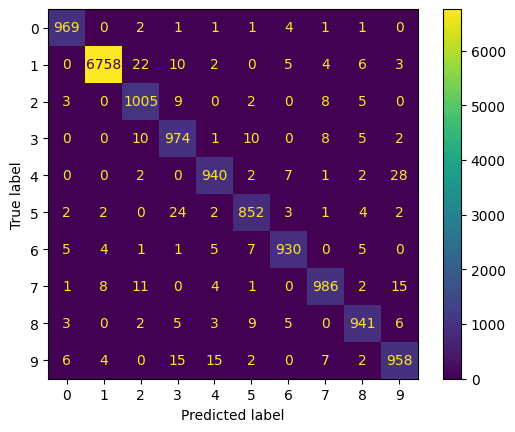

In [ ]:
# Applying the best Hyperparameters on the best performing Model (Gradient Boosting) after Hyperparameter Optimization
pipeline_gb_final = Pipeline([
    ('scaler', StandardScaler()),
    ('gbm', HistGradientBoostingClassifier(
        l2_regularization=1.0,
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42,
        class_weight='balanced'
    ))
])
pipeline_gb_final.fit(X_train_features, y_train)

# --- Model Evaluation ---
y_pred_gb_final = pipeline_gb_final.predict(X_test_features)

accuracy_gb_final = accuracy_score(y_test, y_pred_gb_final)
print(f"Model Accuracy: {accuracy_gb_final:.4f}")
print(classification_report(y_test, y_pred_gb_final))

ConfusionMatrixDisplay.from_estimator(pipeline_gb_final, X_test_features, y_test)
plt.show()

# Before we had an acurracy of 0.9766 - Now it increased on 0.9769. A tiny bit better then before.